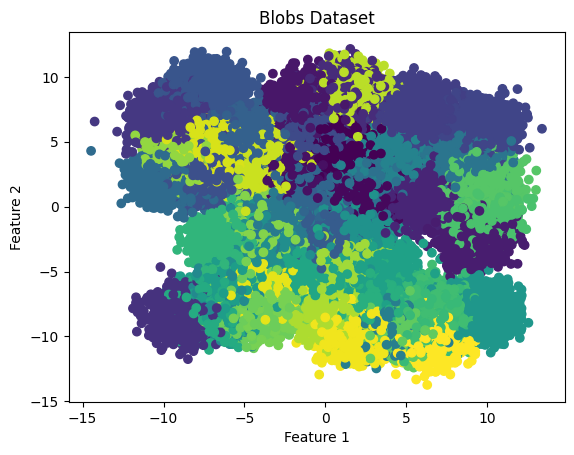

In [63]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, y_original = make_blobs(n_samples=80000, centers=50, n_features=2, random_state=0)
plt.scatter(X[:, 0], X[:, 1], c=y_original)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Blobs Dataset')
plt.show()

Original proportion of positive samples: 0.20


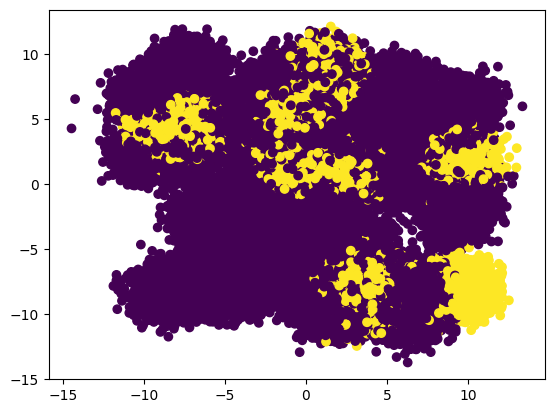

In [64]:
y = (y_original % 5) == 1

plt.scatter(X[:, 0], X[:, 1], c=y)

original_proportion = np.mean(y)

print(f'Original proportion of positive samples: {original_proportion:.2f}')

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)
accuracy = model.score(X_test, y_test)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.86


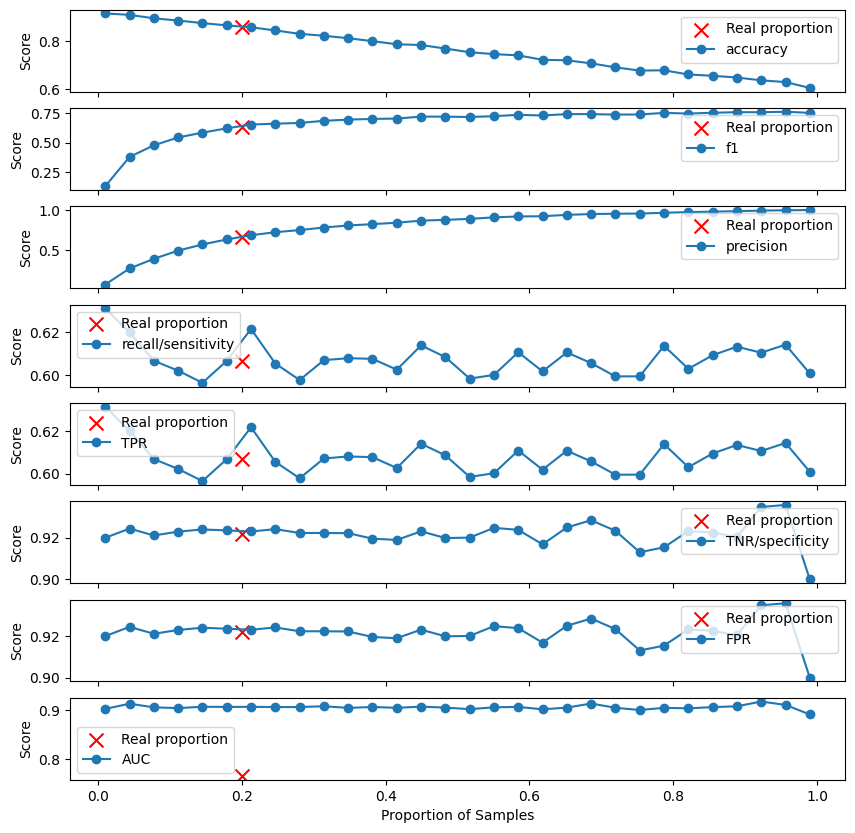

In [ ]:
from sklearn.utils import shuffle

from sklearn.metrics import precision_score, recall_score, roc_auc_score, f1_score, accuracy_score

def true_positive_rate(y_true, y_pred):
    return (y_true[y_true.astype(bool)] == y_pred[y_true.astype(bool)]).sum()/y_true.sum()

def true_negative_rate(y_true, y_pred):
    return (y_true[(1 - y_true).astype(bool)] == y_pred[(1 - y_true).astype(bool)]).sum()/(y_true == 0).sum()

def false_positive_rate(y_true, y_pred):
    return (y_true[(1 - y_true).astype(bool)] == y_pred[(1 - y_true).astype(bool)]).sum()/(y_true == 0).sum()

all_metrics = {'accuracy': accuracy_score,
               'f1': f1_score,
               'precision': precision_score,
               'recall/sensitivity': recall_score,
               'TPR': true_positive_rate,
               'TNR/specificity': true_negative_rate,
               'FPR': false_positive_rate,
               'AUC': roc_auc_score}

y_negatives_mask = y_test == 0

def select_proportion_of_samples(X, y, mask, proportion):
    indices_neg = np.where(mask)[0]
    selected_neg_indices = np.random.choice(indices_neg, size=int(len(y) * (1 - proportion)), replace=True)

    indices_pos = np.where(~mask)[0]
    selected_pos_indices = np.random.choice(indices_pos, size=int(len(y) * proportion), replace=True)

    X = np.concatenate([X[selected_neg_indices], X[selected_pos_indices]])
    y = np.concatenate([y[selected_neg_indices], y[selected_pos_indices]])

    X, y = shuffle(X, y, random_state=0)

    return X, y

proportions = np.linspace(0.01, 0.99, 30)
results = {metric: [] for metric in all_metrics}
for prop in proportions:
    X_subset, y_subset = select_proportion_of_samples(X_test, y_test, y_negatives_mask, prop)
    y_pred_subset = model.predict(X_subset)
    for metric_name, metric_func in all_metrics.items():
        if metric_name == 'AUC':
            score = metric_func(y_subset, model.predict_proba(X_subset)[:, 1])
        else:
            score = metric_func(y_subset, y_pred_subset)
        results[metric_name].append(score)

original_scores = {metric: all_metrics[metric](y_test, model.predict(X_test)) for metric in all_metrics}

fig, ax_list = plt.subplots(nrows=len(all_metrics), figsize=(10, 10))
for metric, ax in zip(all_metrics, ax_list):
    ax.scatter(original_proportion, original_scores[metric],
               label='Real proportion', color='red', marker='x', s=100)
    ax.plot(proportions, results[metric], label=metric, marker='o')
    if ax != ax_list[-1]:
        ax.set_xticklabels([])
    else:
        ax.set_xlabel('Proportion of positives')
    ax.set_ylabel('Score')
    ax.legend()

